In [22]:
# importing libraries and functions
import os
import pandas as pd
from datetime import datetime, timedelta
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from scipy.stats import zscore
import warnings
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV

In [2]:
# Processing manoeuvre and orbital data 

In [3]:
# Helper function for Date conversion
def doy_to_datetime(year: int, doy: int, hour: int, minute: int, second: float=0.0):
    return datetime(year, 1, 1) + timedelta(days=doy - 1, hours=hour, minutes=minute, seconds=second)

In [4]:
# Processing manoeuvre file 'ja1man.txt'
def parse_non_fengyun_line(line):
    parts = line.split()
    if len(parts) < 9:
        return None
    try:
        return {
            'satellite': parts[0],
            'start_time': doy_to_datetime(int(parts[1]), int(parts[2]), int(parts[3]), int(parts[4])),
            'end_time': doy_to_datetime(int(parts[5]), int(parts[6]), int(parts[7]), int(parts[8]))
        }
    except Exception as e:
        print(f"Skipping line due to error: {e}")
        return None

def process_manoeuvre_file(path):
    with open(path) as f:
        data = [parse_non_fengyun_line(line.strip()) for line in f if line.strip()]
    return pd.DataFrame([d for d in data if d])


In [5]:
# Processing orbital elements from 'Jason-1.csv' file

def load_orbital_elements(filepath: str):
    try:
        df = pd.read_csv(filepath, index_col=0, parse_dates=True)
        df.sort_index(inplace=True)
        df.index.name = 'timestamp' 
        return df
    except Exception as e:
        print(f"Error loading orbital elements file: {filepath}\n{e}")
        return pd.DataFrame()   


In [6]:
# Loading both files
def main():
    base_dir = './satellite_data'
    manoeuvre_file = os.path.join(base_dir, 'manoeuvres', 'ja1man.txt')
    orbital_file = os.path.join(base_dir, 'orbital_elements', 'Jason-1.csv')

    print(f"\nProcessing manoeuvre file: {manoeuvre_file}")
    man_df = process_manoeuvre_file(manoeuvre_file)
    print(man_df.head())

    print(f"\nProcessing orbital elements file: {orbital_file}")
    orb_df = load_orbital_elements(orbital_file)
    print(orb_df.head())

    return man_df, orb_df

In [7]:
man_df, orb_df = main()


Processing manoeuvre file: ./satellite_data/manoeuvres/ja1man.txt
  satellite          start_time            end_time
0     JASO1 2001-12-11 13:08:00 2001-12-11 15:57:00
1     JASO1 2001-12-13 21:17:00 2001-12-14 00:06:00
2     JASO1 2001-12-17 07:35:00 2001-12-17 10:31:00
3     JASO1 2001-12-20 06:45:00 2001-12-20 09:39:00
4     JASO1 2002-01-10 01:49:00 2002-01-10 04:40:00

Processing orbital elements file: ./satellite_data/orbital_elements/Jason-1.csv
                            eccentricity  argument of perigee  inclination  \
timestamp                                                                    
2001-12-22 04:13:05.190527      0.000851             4.661221     1.152701   
2001-12-23 23:23:38.458751      0.000839             4.615654     1.152689   
2001-12-24 23:45:59.288255      0.000836             4.609627     1.152690   
2001-12-25 22:15:50.795999      0.000830             4.597215     1.152689   
2001-12-26 11:23:15.892799      0.000822             4.593359     1.1526

<Figure size 1000x400 with 0 Axes>

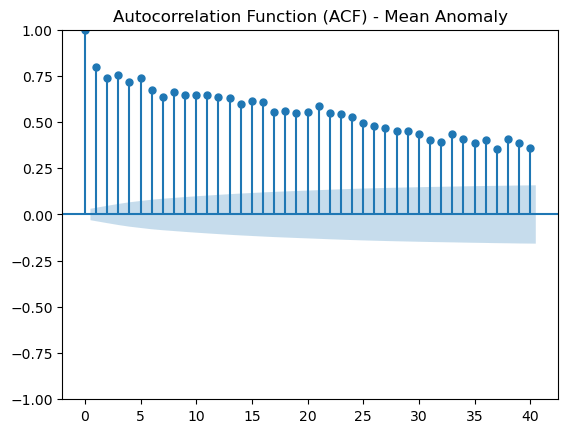

<Figure size 1000x400 with 0 Axes>

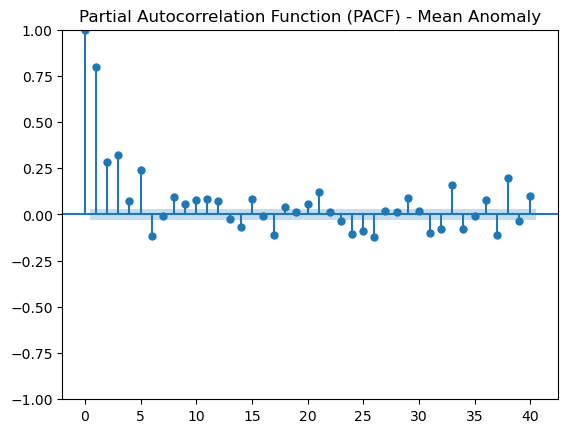


--- Augmented Dickey-Fuller (ADF) Test ---
ADF Statistic     : -3.859661
p-value           : 0.002353
Critical Values   :
   1%: -3.4320
   5%: -2.8623
   10%: -2.5672

 The series is stationary.


In [8]:
# EDA for 'mean anomaly'

# Select the ' mean anomaly' series
series = orb_df['mean anomaly'].dropna()

# ACF plot
plt.figure(figsize=(10, 4))
plot_acf(series, lags=40)
plt.title('Autocorrelation Function (ACF) - Mean Anomaly')
plt.show()

# PACF plot
plt.figure(figsize=(10, 4))
plot_pacf(series, lags=40, method='ywm') 
plt.title('Partial Autocorrelation Function (PACF) - Mean Anomaly')
plt.show()

# ADF Test
result = adfuller(series)
print('\n--- Augmented Dickey-Fuller (ADF) Test ---')
print(f"ADF Statistic     : {result[0]:.6f}")
print(f"p-value           : {result[1]:.6f}")
print(f"Critical Values   :")
for key, value in result[4].items():
    print(f"   {key}: {value:.4f}")
if result[1] < 0.05:
    print("\n The series is stationary.")
else:
    print("\n The series is NOT stationary .")


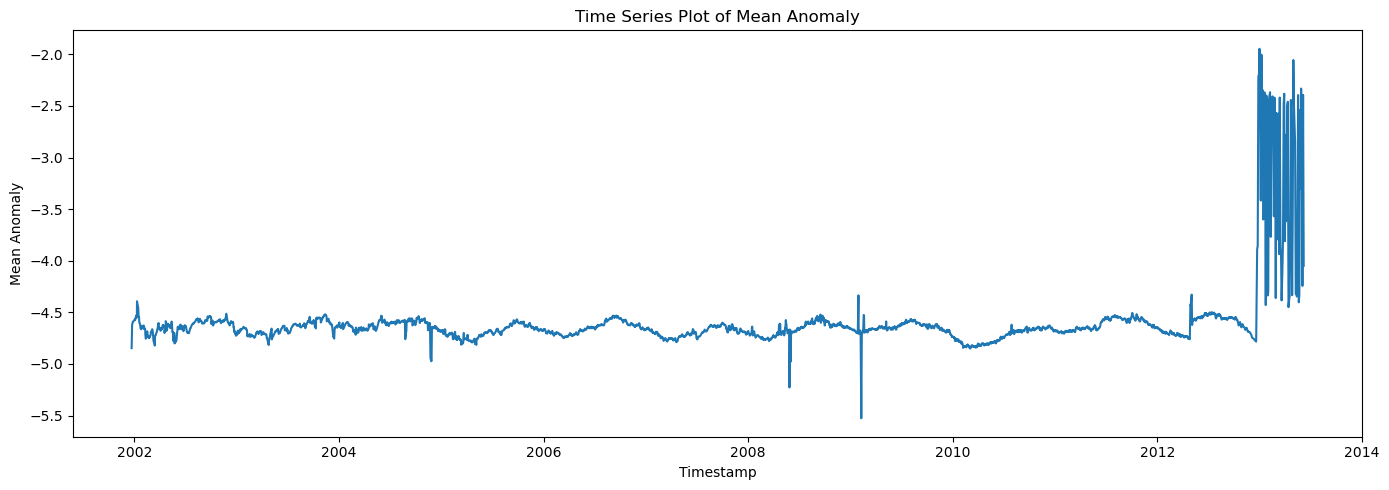

In [9]:
# Plotting the time series to observe trends for mean anomaly

def plot_mean_anomaly_trend(df):
    plt.figure(figsize=(14, 5))
    sns.lineplot(x=df.index, y=df['mean anomaly'])
    plt.title("Time Series Plot of Mean Anomaly")
    plt.xlabel("Timestamp")
    plt.ylabel("Mean Anomaly")
    plt.tight_layout()
    plt.show()
plot_mean_anomaly_trend(orb_df)

In [10]:
# Fill missing values in mean_anomaly
if orb_df['mean anomaly'].isna().sum() > 0:
    orb_df['mean anomaly'] = orb_df['mean anomaly'].ffill()

In [11]:
# Train test split for "mean anomaly" 
train_size = int(len(orb_df) * 0.8)
train_data = orb_df['mean anomaly'][:train_size]
test_data = orb_df['mean anomaly'][train_size:]

print(f"Train data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

Train data shape: (3196,)
Test data shape: (800,)


In [8]:
"""  this is the old one wasmnt working well . So we added below code ----rolling mean and std features
saved the graph in documents mamed 'Jaison_meananomaly_before'
# --- Feature engineering function ---
def create_features(df, target_col='mean anomaly', lags=30):
    """
    Create time series features including lag features.
    """
    if isinstance(df, pd.Series):
        df = df.to_frame(name=target_col)
    
    df = df.copy()
    
    # Create temporal features
    df['dayofyear'] = df.index.dayofyear
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    
    # Create lag features
    for lag in range(1, lags+1):
        df[f'lag_{lag}'] = df[target_col].shift(lag)
    
    # Drop rows with NaN values
    df = df.dropna()
    
    return df
"""

In [12]:
# Feature Engineering Function 
def create_features(df, target_col='mean anomaly', lags=30):
    if isinstance(df, pd.Series):
        df = df.to_frame(name=target_col)   
    df = df.copy()  
    # temporal features
    df['dayofyear'] = df.index.dayofyear
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year  
    # lag features
    for lag in range(1, lags + 1):
        df[f'lag_{lag}'] = df[target_col].shift(lag)
    rolling_windows = [3, 7, 14, 30] 
    for window in rolling_windows:
        df[f'rolling_mean_{window}'] = df[target_col].shift(1).rolling(window=window).mean()
        df[f'rolling_std_{window}'] = df[target_col].shift(1).rolling(window=window).std()
    df = df.dropna()    
    return df


In [15]:
#  Create features
target_col = 'mean anomaly'
train_features = create_features(train_data, target_col)
test_features = create_features(test_data, target_col)

X_train = train_features.drop(columns=[target_col])
y_train = train_features[target_col]
X_test = test_features.drop(columns=[target_col])
y_test = test_features[target_col]

# Scale features using min max
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [20]:
#  model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Cross Validation 
tscv = TimeSeriesSplit(n_splits=3)

In [23]:
# Grid Search 
print("Starting Grid Search...")
grid_search = GridSearchCV(estimator=xgb_model,
                         param_grid=param_grid,
                         cv=tscv,
                         scoring='neg_mean_squared_error',
                         n_jobs=-1,
                         verbose=1)
grid_search.fit(X_train_scaled, y_train)

#  best model 
best_xgb = grid_search.best_estimator_
print("\nBest parameters:", grid_search.best_params_)


Starting Grid Search...
Fitting 3 folds for each of 32 candidates, totalling 96 fits

Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [24]:
# Train final model 
best_xgb.fit(X_train_scaled, y_train,
            eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
            verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [26]:
test_features = create_features(test_data, target_col)
X_test = test_features.drop(columns=[target_col])
y_test = test_features[target_col]

In [27]:
# Make predictions for the full test set
test_predictions = best_xgb.predict(X_test_scaled)

In [28]:
#  RMSE 
train_predictions = best_xgb.predict(X_train_scaled)
train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

print(f"\nTrain RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")


Train RMSE: 0.0145
Test RMSE: 0.5038


In [29]:
print(len(test_data))
print(len(test_predictions))

800
770


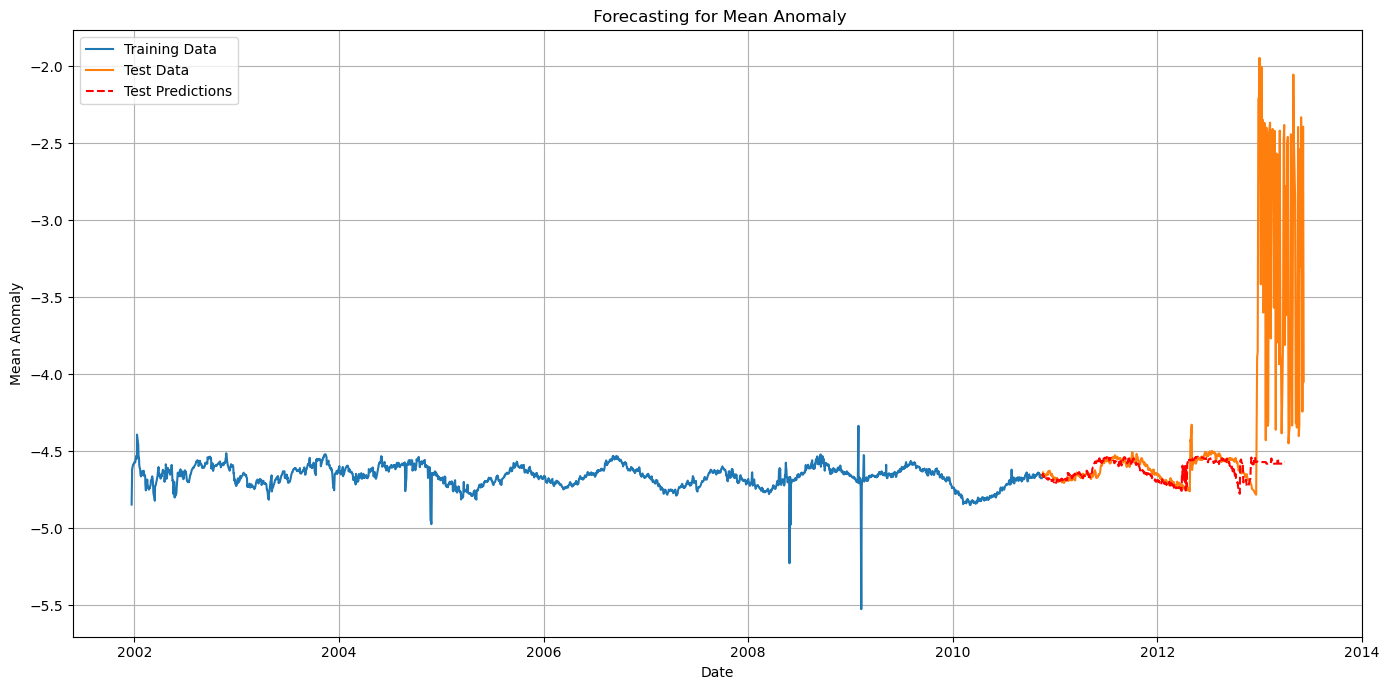

In [30]:
# Plotting prediction vs observed for "mean anomaly"
plt.figure(figsize=(14, 7))
plt.plot(train_data.index, train_data, label='Training Data')
plt.plot(test_data.index, test_data, label='Test Data')
plt.plot(test_data.index[:len(test_predictions)], test_predictions, label='Test Predictions', color='red', linestyle='--') 
plt.title(" Forecasting for Mean Anomaly")
plt.xlabel("Date")
plt.ylabel("Mean Anomaly")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

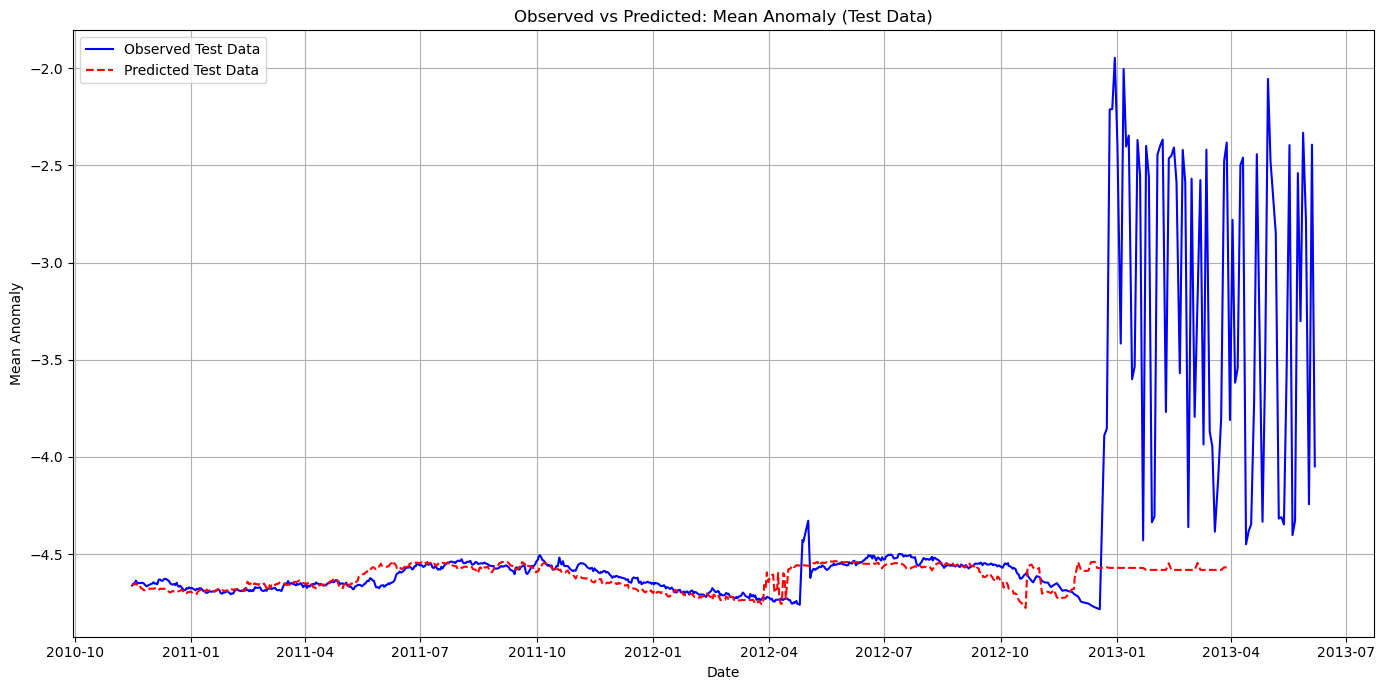

In [31]:
# Plotting only the observed vs predicted for "mean anomaly" test data
plt.figure(figsize=(14, 7))

# Plotting the observed values
plt.plot(test_data.index, test_data, label='Observed Test Data', color='blue')

# Plotting the predicted values
plt.plot(test_data.index[:len(test_predictions)], test_predictions, label='Predicted Test Data', color='red', linestyle='--')

plt.title("Observed vs Predicted: Mean Anomaly (Test Data)")
plt.xlabel("Date")
plt.ylabel("Mean Anomaly")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

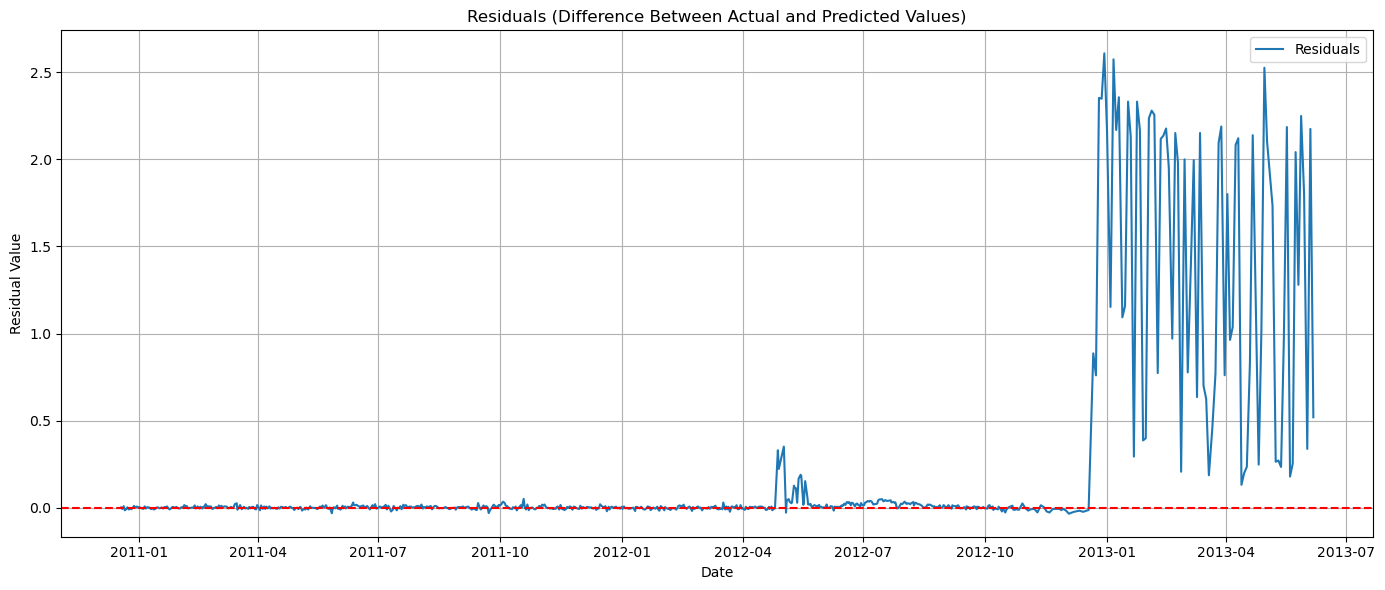

In [32]:
# Calculate residuals for predictions 
residuals = y_test - test_predictions

# Plotting Residuals 
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, residuals, label='Residuals')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals (Difference Between Actual and Predicted Values)')
plt.xlabel('Date')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [33]:
# Absolute Residuals
abs_residuals = np.abs(residuals)

# Threshold for Manoeuvre Detection 
threshold_std = abs_residuals.mean() + 2 * abs_residuals.std()
threshold = threshold_std 
print(f"Threshold value used: {threshold:.8f}")

#  Detect Manoeuvres 
detected_manoeuvres = residuals[abs_residuals > threshold]
print(f"Number of detected manoeuvre points: {len(detected_manoeuvres)}")

# Group detected points into events
detected_dates = detected_manoeuvres.index.tolist()
manoeuvre_events = []

if detected_dates:
    current_event = [detected_dates[0]]

    for i in range(1, len(detected_dates)):
        if (detected_dates[i] - current_event[-1]).days <= 2:
            current_event.append(detected_dates[i])
        else:
            manoeuvre_events.append({
                'start_time': current_event[0],
                'end_time': current_event[-1],
                'max_residual': abs_residuals[current_event].max()
            })
            current_event = [detected_dates[i]]
    manoeuvre_events.append({
        'start_time': current_event[0],
        'end_time': current_event[-1],
        'max_residual': abs_residuals[current_event].max()
    })
detected_df = pd.DataFrame(manoeuvre_events)

print("\nDetected Manoeuvre Events:")
print(detected_df)

Threshold value used: 1.11070548
Number of detected manoeuvre points: 41

Detected Manoeuvre Events:
                   start_time                   end_time  max_residual
0  2012-12-26 04:04:35.690592 2013-01-10 04:51:01.075391      2.608896
1  2013-01-14 20:39:54.203327 2013-01-19 03:46:47.585279      2.331755
2  2013-01-23 21:51:50.792256 2013-01-26 02:09:35.173152      2.331658
3  2013-02-01 20:50:16.342079 2013-02-05 23:56:34.888992      2.280118
4  2013-02-10 19:49:13.077120 2013-02-16 21:36:09.891935      2.177565
5  2013-02-21 19:25:42.299039 2013-02-23 19:59:03.198624      2.151540
6  2013-02-28 19:38:11.001696 2013-02-28 19:38:11.001696      2.000129
7  2013-03-05 13:29:26.779199 2013-03-07 18:00:57.996000      1.995437
8  2013-03-12 12:06:03.387167 2013-03-12 12:06:03.387167      2.151808
9  2013-03-26 12:35:51.043776 2013-03-28 13:13:24.167424      2.188870
10 2013-04-02 03:24:07.947359 2013-04-02 03:24:07.947359      1.801099
11 2013-04-08 09:02:51.117792 2013-04-10 09:39:

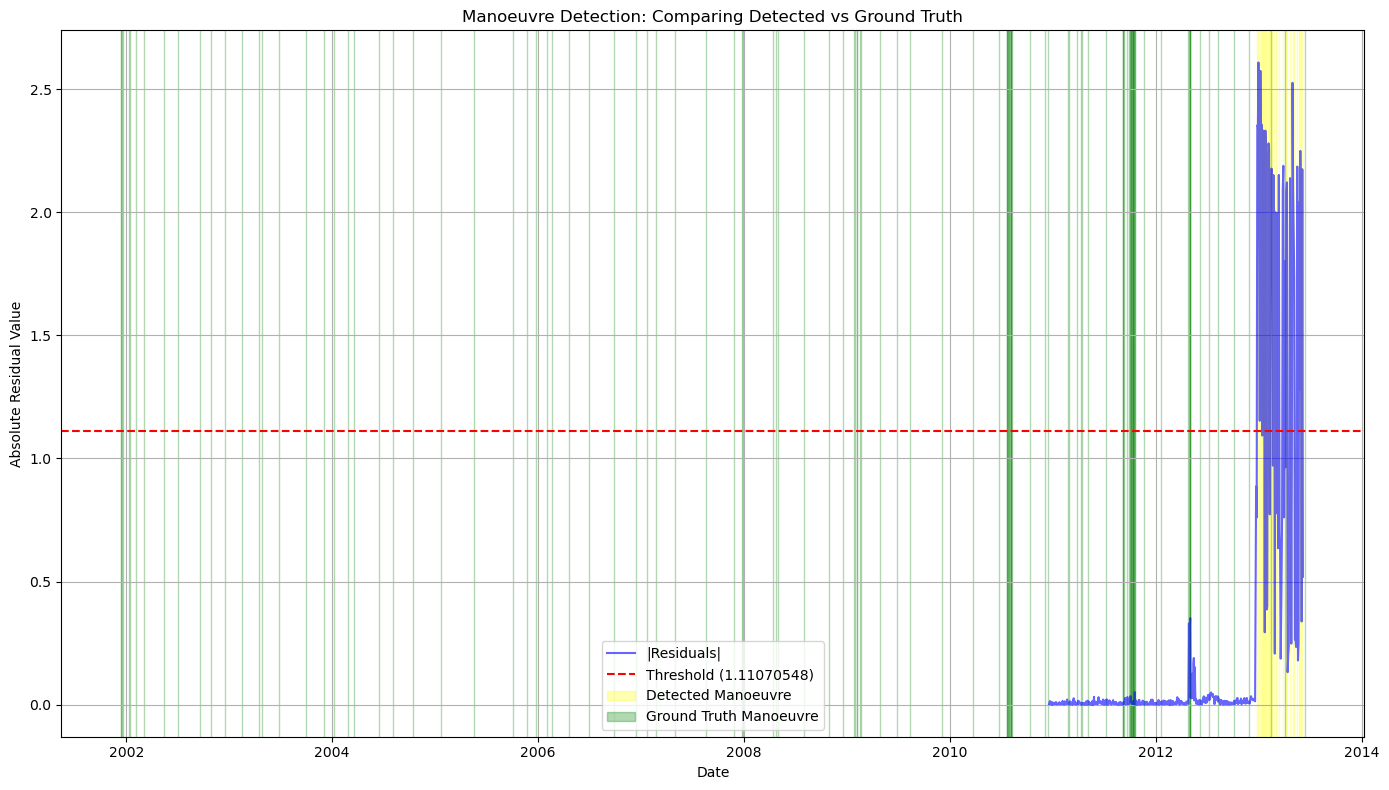

In [34]:
# Plotting Detected Manoeuvres vs Ground Truth
plt.figure(figsize=(14, 8))

# absolute residuals
plt.plot(abs_residuals.index, abs_residuals, label='|Residuals|', color='blue', alpha=0.6)
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold ({threshold:.8f})')

# detected manoeuvre 
for idx, event in enumerate(manoeuvre_events):
    plt.axvspan(event['start_time'], event['end_time'], 
                alpha=0.3, color='yellow', label='Detected Manoeuvre' if idx == 0 else '')

#  ground truth manoeuvres 
for idx, row in man_df.iterrows():
    plt.axvspan(row['start_time'], row['end_time'], 
                alpha=0.3, color='green', label='Ground Truth Manoeuvre' if idx == 0 else '')

plt.title('Manoeuvre Detection: Comparing Detected vs Ground Truth')
plt.xlabel('Date')
plt.ylabel('Absolute Residual Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [35]:
# Calculate Detection Accuracy Metrics 
def calculate_detection_accuracy(detected_df, ground_truth_df, tolerance_days=3):
    true_positives = 0
    false_positives = 0
    for _, det_event in detected_df.iterrows():
        matched = False
        for _, gt_event in ground_truth_df.iterrows():
            if (
                (det_event['start_time'] <= gt_event['end_time'] and 
                 det_event['end_time'] >= gt_event['start_time']) or
                (abs((det_event['start_time'] - gt_event['start_time']).days) <= tolerance_days or
                 abs((det_event['end_time'] - gt_event['end_time']).days) <= tolerance_days)
            ):
                matched = True
                break
        if matched:
            true_positives += 1
        else:
            false_positives += 1
    # False negatives
    false_negatives = 0
    for _, gt_event in ground_truth_df.iterrows():
        matched = False
        for _, det_event in detected_df.iterrows():
            if (
                (det_event['start_time'] <= gt_event['end_time'] and 
                 det_event['end_time'] >= gt_event['start_time']) or
                (abs((det_event['start_time'] - gt_event['start_time']).days) <= tolerance_days or
                 abs((det_event['end_time'] - gt_event['end_time']).days) <= tolerance_days)
            ):
                matched = True
                break
        if not matched:
            false_negatives += 1

    # Metrics
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return {
        'true_positives': true_positives,
        'false_positives': false_positives,
        'false_negatives': false_negatives,
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score
    }


In [36]:
metrics = calculate_detection_accuracy(detected_df, man_df)
print(f"True Positives: {metrics['true_positives']}")
print(f"False Positives: {metrics['false_positives']}")
print(f"False Negatives: {metrics['false_negatives']}")
print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall: {metrics['recall']:.4f}")
print(f"F1 Score: {metrics['f1_score']:.4f}")


True Positives: 2
False Positives: 16
False Negatives: 117
Precision: 0.1111
Recall: 0.0168
F1 Score: 0.0292


In [37]:
# summary 

print("\n[ XGBoost ] Detected Manoeuvres:")
print(detected_df[['start_time', 'end_time', 'max_residual']])

print("\nGround Truth Manoeuvres:")
print(man_df[['start_time', 'end_time']])



[ XGBoost ] Detected Manoeuvres:
                   start_time                   end_time  max_residual
0  2012-12-26 04:04:35.690592 2013-01-10 04:51:01.075391      2.608896
1  2013-01-14 20:39:54.203327 2013-01-19 03:46:47.585279      2.331755
2  2013-01-23 21:51:50.792256 2013-01-26 02:09:35.173152      2.331658
3  2013-02-01 20:50:16.342079 2013-02-05 23:56:34.888992      2.280118
4  2013-02-10 19:49:13.077120 2013-02-16 21:36:09.891935      2.177565
5  2013-02-21 19:25:42.299039 2013-02-23 19:59:03.198624      2.151540
6  2013-02-28 19:38:11.001696 2013-02-28 19:38:11.001696      2.000129
7  2013-03-05 13:29:26.779199 2013-03-07 18:00:57.996000      1.995437
8  2013-03-12 12:06:03.387167 2013-03-12 12:06:03.387167      2.151808
9  2013-03-26 12:35:51.043776 2013-03-28 13:13:24.167424      2.188870
10 2013-04-02 03:24:07.947359 2013-04-02 03:24:07.947359      1.801099
11 2013-04-08 09:02:51.117792 2013-04-10 09:39:55.515168      2.121533
12 2013-04-21 07:23:19.453056 2013-04-21 07

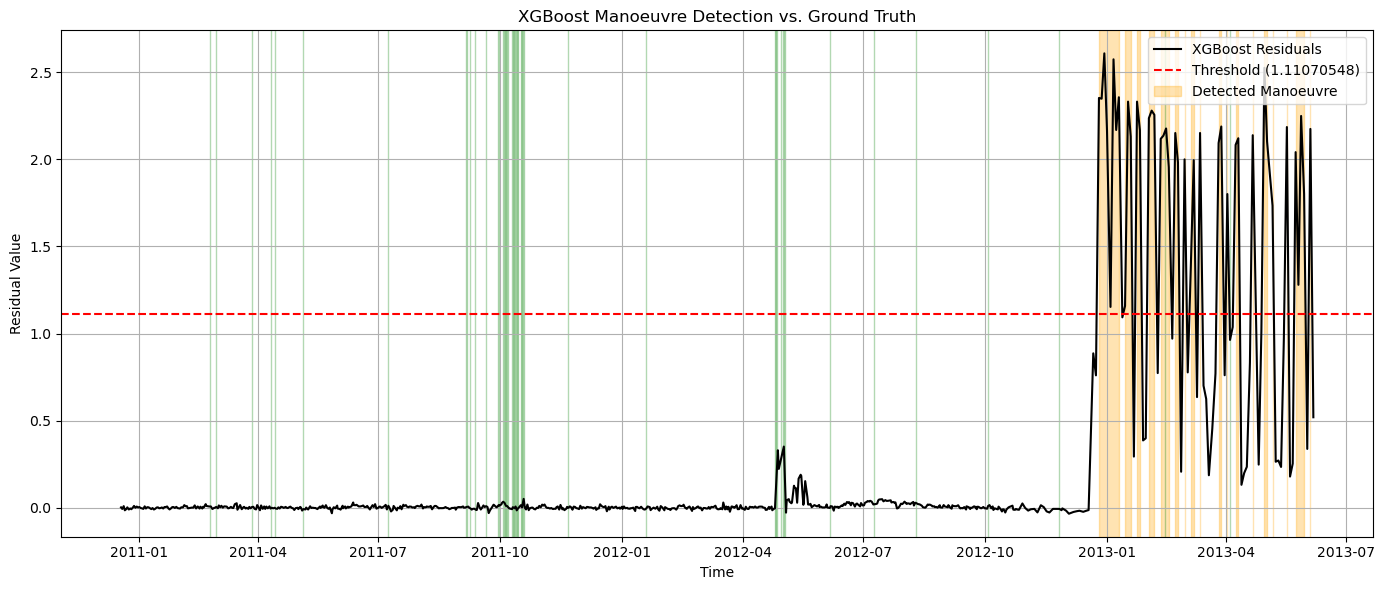

In [38]:
# Filter ground truth manoeuvres
man_df_filtered = man_df[
    (man_df['start_time'] >= residuals.index.min()) &
    (man_df['end_time'] <= residuals.index.max())
]
plt.figure(figsize=(14, 6))

#  residuals
plt.plot(residuals.index, residuals.values, label='XGBoost Residuals', color='black')

# threshold 
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold ({threshold:.8f})')

# detected manoeuvres 
if not detected_df.empty:
    for idx, row in detected_df.iterrows():
        plt.axvspan(row['start_time'], row['end_time'], color='orange', alpha=0.3,
                    label='Detected Manoeuvre' if idx == 0 else "")

# ground truth manoeuvres 
if not man_df_filtered.empty:
    for idx, row in man_df_filtered.iterrows():
        plt.axvspan(row['start_time'], row['end_time'], color='green', alpha=0.3,
                    label='Ground Truth Manoeuvre' if idx == 0 else "")

plt.xlabel('Time')
plt.ylabel('Residual Value')
plt.title('XGBoost Manoeuvre Detection vs. Ground Truth')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()


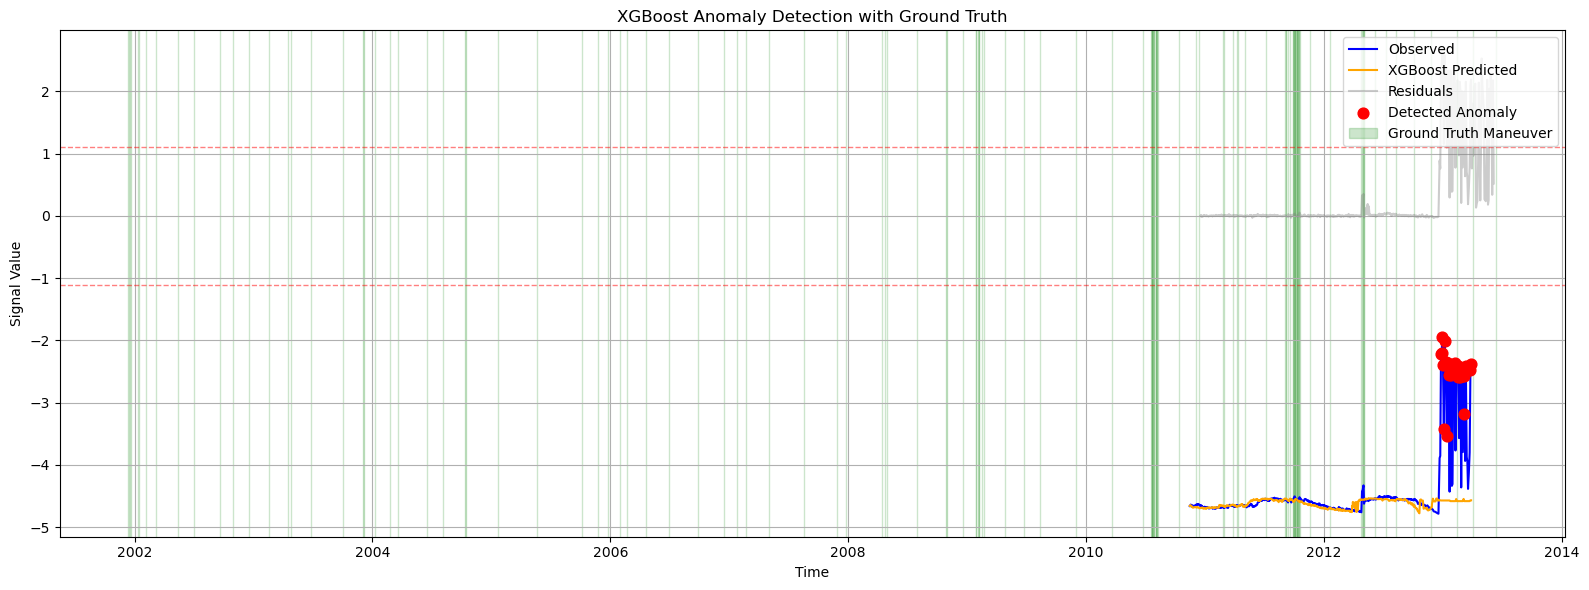

In [39]:
def detect_anomalies(residuals, threshold):
    anomaly_mask = residuals.abs() > threshold
    return residuals[anomaly_mask]

def plot_all_in_one_xgboost(observed, predicted, residuals, threshold, man_df):
    if len(predicted) != len(observed):
        print(f"Warning: Length mismatch. Observed: {len(observed)}, Predicted: {len(predicted)}")
        min_len = min(len(observed), len(predicted))
        observed = observed[:min_len]
        predicted = predicted[:min_len]
        residuals = residuals[:min_len]
    predicted = pd.Series(predicted, index=observed.index)
    anomalies = detect_anomalies(residuals, threshold)
    anomalies = anomalies[anomalies.index.isin(observed.index)]
    fig, ax = plt.subplots(figsize=(16, 6))

    #  Observed and Predicted 
    ax.plot(observed.index, observed.values, label='Observed', color='blue', linewidth=1.5)
    ax.plot(predicted.index, predicted.values, label='XGBoost Predicted', color='orange', linewidth=1.5)

    # residuals
    ax.plot(residuals.index, residuals.values, color='grey', alpha=0.4, label='Residuals')

    #  anomalies
    ax.scatter(anomalies.index, observed.loc[anomalies.index], color='red', s=60, label='Detected Anomaly', zorder=5)

    # threshold 
    ax.axhline(y=threshold, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax.axhline(y=-threshold, color='red', linestyle='--', linewidth=1, alpha=0.5)

    # Ground Truth Maneuvers
    for idx, row in man_df.iterrows():
        ax.axvspan(row['start_time'], row['end_time'], color='green', alpha=0.2,
                   label='Ground Truth Maneuver' if idx == 0 else "")

    ax.set_title("XGBoost Anomaly Detection with Ground Truth")
    ax.set_xlabel("Time")
    ax.set_ylabel("Signal Value")
    ax.legend(loc='upper right')
    ax.grid(True)
    plt.tight_layout()
    plt.show()
plot_all_in_one_xgboost(test_data, test_predictions, residuals, threshold, man_df)


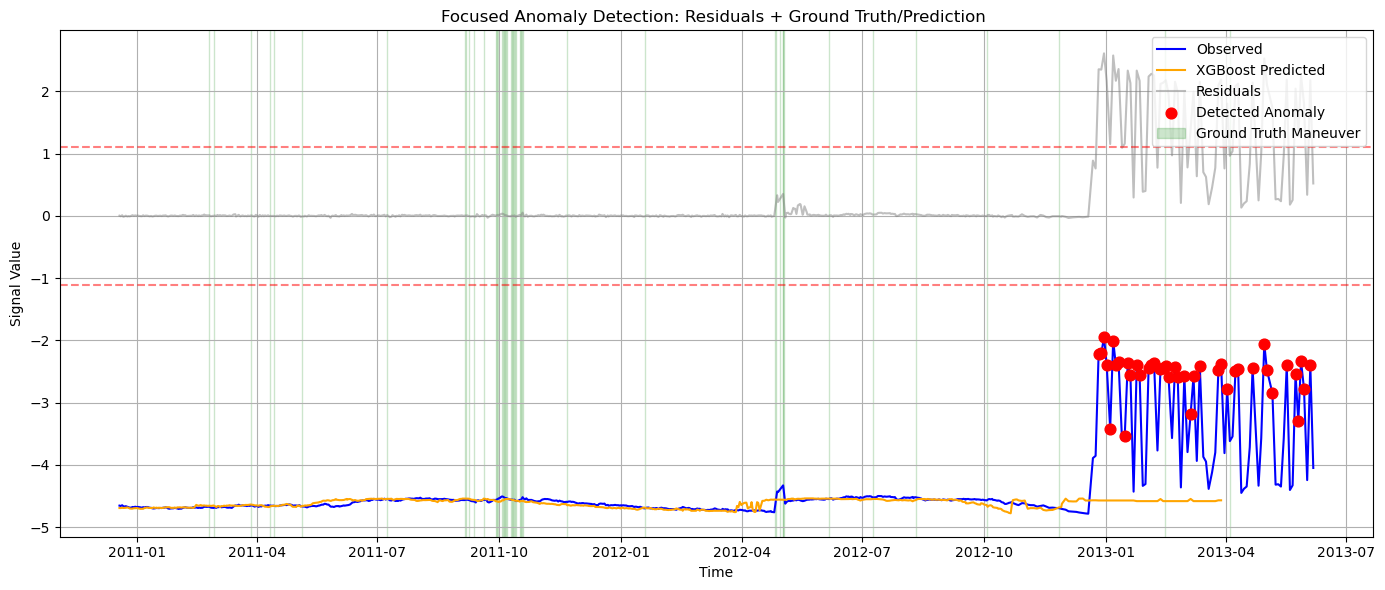

In [40]:
def plot_focused_anomalies_xgboost(observed, predicted, residuals, threshold, man_df):
    if len(predicted) != len(observed):
        predicted = pd.Series(predicted, index=observed.index[:len(predicted)])
    valid_times = residuals.dropna().index
    valid_man = man_df[
        (man_df['end_time'] >= valid_times.min()) &
        (man_df['start_time'] <= valid_times.max())
    ]
    plot_start = max(valid_times.min(), predicted.dropna().index.min())
    plot_end = max(valid_times.max(), predicted.dropna().index.max())
    observed = observed[(observed.index >= plot_start) & (observed.index <= plot_end)]
    predicted = predicted[(predicted.index >= plot_start) & (predicted.index <= plot_end)]
    residuals = residuals[(residuals.index >= plot_start) & (residuals.index <= plot_end)]
    anomalies = detect_anomalies(residuals, threshold)
    anomalies = anomalies[(anomalies.index >= plot_start) & (anomalies.index <= plot_end)]
    valid_man = valid_man[
        (valid_man['start_time'] <= plot_end) &
        (valid_man['end_time'] >= plot_start)
    ]

    # Plot
    fig, ax = plt.subplots(figsize=(14, 6))

    #  Observed and Predicted 
    ax.plot(observed.index, observed.values, label='Observed', color='blue', linewidth=1.5)
    ax.plot(predicted.index, predicted.values, label='XGBoost Predicted', color='orange', linewidth=1.5)
    ax.plot(residuals.index, residuals.values, color='grey', alpha=0.5, label='Residuals')

    # Detected anomalies
    ax.scatter(anomalies.index, observed.loc[anomalies.index], color='red', s=60, label='Detected Anomaly', zorder=5)

    # Residual threshold 
    ax.axhline(threshold, linestyle='--', color='red', alpha=0.5)
    ax.axhline(-threshold, linestyle='--', color='red', alpha=0.5)

    # Ground truth  
    for idx, row in valid_man.iterrows():
        ax.axvspan(row['start_time'], row['end_time'], color='green', alpha=0.2,
                   label='Ground Truth Maneuver' if idx == valid_man.index[0] else "")

    ax.set_title("Focused Anomaly Detection: Residuals + Ground Truth/Prediction ")
    ax.set_xlabel("Time")
    ax.set_ylabel("Signal Value")
    ax.legend(loc='upper right')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

plot_focused_anomalies_xgboost(test_data, test_predictions, residuals, threshold, man_df)


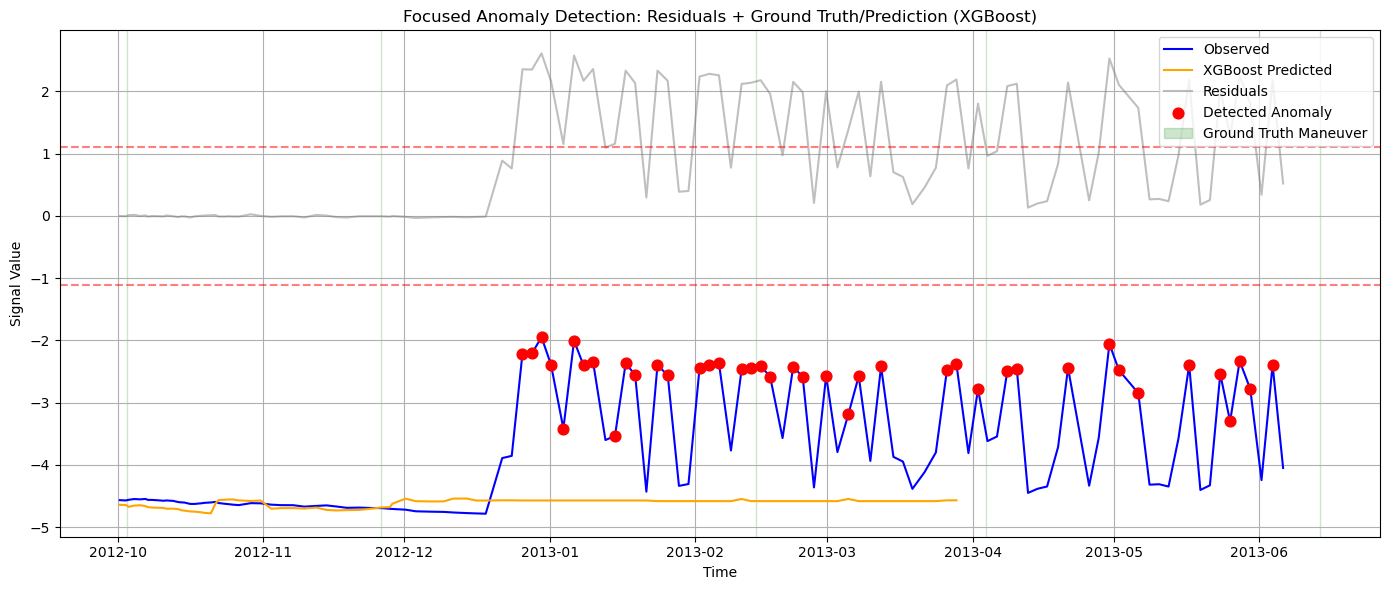

In [41]:
#start and end time
plot_start = '2012-10-01'
plot_end = '2013-07-31'

plot_start = pd.to_datetime(plot_start)
plot_end = pd.to_datetime(plot_end)

def plot_focused_anomalies_xgboost(observed, predicted, residuals, threshold, man_df):
    if len(predicted) != len(observed):
        predicted = pd.Series(predicted, index=observed.index[:len(predicted)])
    observed = observed[(observed.index >= plot_start) & (observed.index <= plot_end)]
    predicted = predicted[(predicted.index >= plot_start) & (predicted.index <= plot_end)]
    residuals = residuals[(residuals.index >= plot_start) & (residuals.index <= plot_end)]

    anomalies = detect_anomalies(residuals, threshold)
    anomalies = anomalies[(anomalies.index >= plot_start) & (anomalies.index <= plot_end)]

    valid_man = man_df[
        (man_df['end_time'] >= plot_start) &
        (man_df['start_time'] <= plot_end)
    ]

    # Plot
    fig, ax = plt.subplots(figsize=(14, 6))

    #  Observed and Predicted 
    ax.plot(observed.index, observed.values, label='Observed', color='blue', linewidth=1.5)
    ax.plot(predicted.index, predicted.values, label='XGBoost Predicted', color='orange', linewidth=1.5)
    ax.plot(residuals.index, residuals.values, color='grey', alpha=0.5, label='Residuals')

    # Detected anomalies
    ax.scatter(anomalies.index, observed.loc[anomalies.index], color='red', s=60, label='Detected Anomaly', zorder=5)

    # Residual threshold 
    ax.axhline(threshold, linestyle='--', color='red', alpha=0.5)
    ax.axhline(-threshold, linestyle='--', color='red', alpha=0.5)

    # Ground truth  
    for idx, row in valid_man.iterrows():
        ax.axvspan(row['start_time'], row['end_time'], color='green', alpha=0.2,
                   label='Ground Truth Maneuver' if idx == valid_man.index[0] else "")

    ax.set_title("Focused Anomaly Detection: Residuals + Ground Truth/Prediction (XGBoost)")
    ax.set_xlabel("Time")
    ax.set_ylabel("Signal Value")
    ax.legend(loc='upper right')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

plot_focused_anomalies_xgboost(test_data, test_predictions, residuals, threshold, man_df)